# **INFO 6154 - Machine Learning Optimization**
### **Assignment 1 - Time Series Prediction**
### **Student Name:** Bernardo Silva
### **Student ID:** 1229489

# **Import libraries**

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
import time

# **Step 1: Load Data**

In [2]:
# Load energy dataset
energy_df = pd.read_csv("/content/energy_dataset.csv")
energy_df = energy_df[["time", "generation fossil gas"]] # Keep only the time and the target value "generation fossil gas"
energy_df["time"] = pd.to_datetime(energy_df["time"], format="%Y-%m-%d %H:%M:%S%z", utc=True) # Convert the time column to a datetime object
energy_df.set_index("time", inplace=True)
# Rename the column "generation fossil gas" to "target_column"
energy_df

,generation fossil gas
time,
2014-12-31 23:00:00+00:00,4844.0
2015-01-01 00:00:00+00:00,5196.0
2015-01-01 01:00:00+00:00,4857.0
2015-01-01 02:00:00+00:00,4314.0
2015-01-01 03:00:00+00:00,4130.0
...,...
2018-12-31 18:00:00+00:00,7634.0
2018-12-31 19:00:00+00:00,7241.0
2018-12-31 20:00:00+00:00,7025.0


In [3]:
# Replace any space with "_" in the column names
energy_df.columns = energy_df.columns.str.replace(" ", "_")
energy_df

,generation_fossil_gas
time,
2014-12-31 23:00:00+00:00,4844.0
2015-01-01 00:00:00+00:00,5196.0
2015-01-01 01:00:00+00:00,4857.0
2015-01-01 02:00:00+00:00,4314.0
2015-01-01 03:00:00+00:00,4130.0
...,...
2018-12-31 18:00:00+00:00,7634.0
2018-12-31 19:00:00+00:00,7241.0
2018-12-31 20:00:00+00:00,7025.0


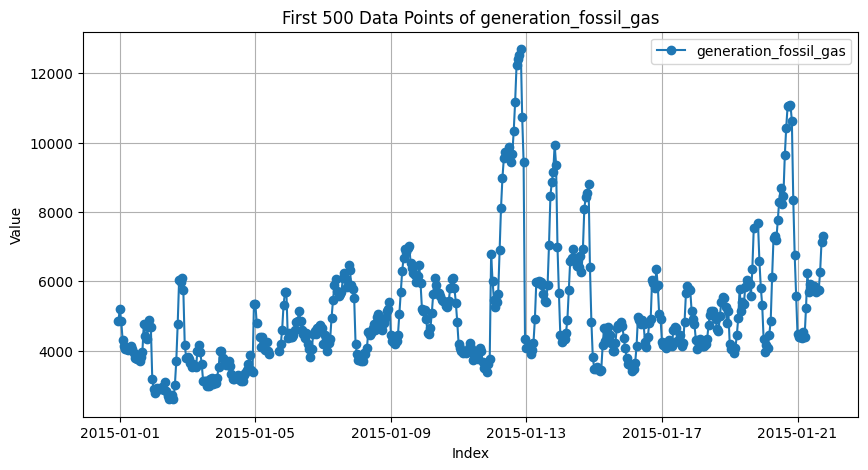

In [4]:
import matplotlib.pyplot as plt

# Select first column name dynamically
target_column = energy_df.columns[0]
Horizon = 500

# Plot first Horizon data points
plt.figure(figsize=(10, 5))
plt.plot(energy_df[target_column][:Horizon], marker="o", linestyle="-", label=target_column)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title(f"First {Horizon} Data Points of {target_column}")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
# Load weather dataset
weather_df = pd.read_csv("/content/weather_features.csv")
weather_df["dt_iso"] = pd.to_datetime(weather_df["dt_iso"], format="%Y-%m-%d %H:%M:%S%z", utc=True) # Convert the time column to a datetime object
weather_df.set_index("dt_iso", inplace=True)
# sort by index
weather_df = weather_df.sort_index()
weather_df

,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
dt_iso,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,Valencia,270.475000,270.475000,270.475000,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2014-12-31 23:00:00+00:00,Madrid,267.325000,267.325000,267.325000,971,63,1,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2014-12-31 23:00:00+00:00,Bilbao,269.657312,269.657312,269.657312,1036,97,0,226,0.0,0.0,0.0,0,800,clear,sky is clear,01
2014-12-31 23:00:00+00:00,Barcelona,281.625000,281.625000,281.625000,1035,100,7,58,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2014-12-31 23:00:00+00:00,Seville,273.375000,273.375000,273.375000,1039,75,1,21,0.0,0.0,0.0,0,800,clear,sky is clear,01n
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-31 22:00:00+00:00,Valencia,279.140000,278.150000,280.150000,1029,75,2,300,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2018-12-31 22:00:00+00:00,Barcelona,280.130000,277.150000,283.150000,1028,100,5,310,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2018-12-31 22:00:00+00:00,Madrid,275.150000,275.150000,275.150000,1031,74,1,360,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [6]:
weather_df["city_name"].unique()

array(['Valencia', 'Madrid', 'Bilbao', ' Barcelona', 'Seville'],
      dtype=object)

We can see from above that in the "weather" dataset there information about 5 different cities. This way, I will create 5 differente datasets to merge "weather" and "energy".

For this project, let's work with the city "Madrid"

In [7]:
# Keep only the rows where city = "Barcelona" in the weather_df
weather_df = weather_df[weather_df["city_name"] == "Madrid"]
weather_df

,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
dt_iso,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,Madrid,267.325,267.325,267.325,971,63,1,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 00:00:00+00:00,Madrid,267.325,267.325,267.325,971,63,1,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 01:00:00+00:00,Madrid,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 02:00:00+00:00,Madrid,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 03:00:00+00:00,Madrid,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-31 18:00:00+00:00,Madrid,283.560,282.150,285.150,1030,88,1,280,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2018-12-31 19:00:00+00:00,Madrid,280.120,278.150,281.150,1031,52,1,260,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2018-12-31 20:00:00+00:00,Madrid,278.150,278.150,278.150,1030,65,1,340,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [9]:
# Merge the datasets
df = energy_df.merge(weather_df, left_index=True, right_index=True, how="left")
df = df.groupby(df.index).first()
print(df.shape)
df.head()

(35064, 17)


,generation_fossil_gas,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
2014-12-31 23:00:00+00:00,4844.0,Madrid,267.325,267.325,267.325,971,63,1,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 00:00:00+00:00,5196.0,Madrid,267.325,267.325,267.325,971,63,1,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 01:00:00+00:00,4857.0,Madrid,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 02:00:00+00:00,4314.0,Madrid,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 03:00:00+00:00,4130.0,Madrid,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2014-12-31 23:00:00+00:00 to 2018-12-31 22:00:00+00:00
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   generation_fossil_gas  35046 non-null  float64
 1   city_name              35064 non-null  object 
 2   temp                   35064 non-null  float64
 3   temp_min               35064 non-null  float64
 4   temp_max               35064 non-null  float64
 5   pressure               35064 non-null  int64  
 6   humidity               35064 non-null  int64  
 7   wind_speed             35064 non-null  int64  
 8   wind_deg               35064 non-null  int64  
 9   rain_1h                35064 non-null  float64
 10  rain_3h                35064 non-null  float64
 11  snow_3h                35064 non-null  float64
 12  clouds_all             35064 non-null  int64  
 13  weather_id             35064 non-null  int64  
 14  weather

In [11]:
# Drop the non-numerical columns
df = df.drop(columns=["city_name", "weather_main", "weather_description", "weather_icon"])
print(df.shape)
df.head()

(35064, 13)


,generation_fossil_gas,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
2014-12-31 23:00:00+00:00,4844.0,267.325,267.325,267.325,971,63,1,309,0.0,0.0,0.0,0,800
2015-01-01 00:00:00+00:00,5196.0,267.325,267.325,267.325,971,63,1,309,0.0,0.0,0.0,0,800
2015-01-01 01:00:00+00:00,4857.0,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800
2015-01-01 02:00:00+00:00,4314.0,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800
2015-01-01 03:00:00+00:00,4130.0,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800


# **Step 2: Data Overview and Summary Statistics**

In [12]:
# Display basic information about the dataset
print("Dataset Information:")
df.info()

# Display first few rows
print("\nFirst few rows of the dataset:")
display(df.head())

# Count missing values in each column
print("\nNumber of missing values per column:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2014-12-31 23:00:00+00:00 to 2018-12-31 22:00:00+00:00
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   generation_fossil_gas  35046 non-null  float64
 1   temp                   35064 non-null  float64
 2   temp_min               35064 non-null  float64
 3   temp_max               35064 non-null  float64
 4   pressure               35064 non-null  int64  
 5   humidity               35064 non-null  int64  
 6   wind_speed             35064 non-null  int64  
 7   wind_deg               35064 non-null  int64  
 8   rain_1h                35064 non-null  float64
 9   rain_3h                35064 non-null  float64
 10  snow_3h                35064 non-null  float64
 11  clouds_all             35064 non-null  int64  
 12  weather_id             35064 non-null  int64  
dtypes: float64(7), int64(6)
memory usage: 

,generation_fossil_gas,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
2014-12-31 23:00:00+00:00,4844.0,267.325,267.325,267.325,971,63,1,309,0.0,0.0,0.0,0,800
2015-01-01 00:00:00+00:00,5196.0,267.325,267.325,267.325,971,63,1,309,0.0,0.0,0.0,0,800
2015-01-01 01:00:00+00:00,4857.0,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800
2015-01-01 02:00:00+00:00,4314.0,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800
2015-01-01 03:00:00+00:00,4130.0,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800



Number of missing values per column:
generation_fossil_gas    18
temp                      0
temp_min                  0
temp_max                  0
pressure                  0
humidity                  0
wind_speed                0
wind_deg                  0
rain_1h                   0
rain_3h                   0
snow_3h                   0
clouds_all                0
weather_id                0
dtype: int64


# **Step 3: Handling Missing Values**

In [13]:
def remove_leading_trailing_zeros_nans(df, column_name):
    """
    Removes leading and trailing rows where the specified column contains either
    zero (0) or NaN (missing values).
    """
    # Remove leading rows where column is 0 or NaN
    while len(df) > 0 and (pd.isna(df[column_name].iloc[0]) or df[column_name].iloc[0] == 0):
        df = df.iloc[1:]

    # Remove trailing rows where column is 0 or NaN
    while len(df) > 0 and (pd.isna(df[column_name].iloc[-1]) or df[column_name].iloc[-1] == 0):
        df = df.iloc[:-1]

    return df


# Apply function
df = remove_leading_trailing_zeros_nans(df, target_column)

# Count missing values in each column
print("\nNumber of missing values per column:")
print(df.isnull().sum())


Number of missing values per column:
generation_fossil_gas    18
temp                      0
temp_min                  0
temp_max                  0
pressure                  0
humidity                  0
wind_speed                0
wind_deg                  0
rain_1h                   0
rain_3h                   0
snow_3h                   0
clouds_all                0
weather_id                0
dtype: int64


In [14]:
numerical_columns = df.columns.tolist()

df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].mean())
# df[categorical_columns] = df[categorical_columns].fillna(df[categorical_columns].mode().iloc[0])

# Select only numerical columns
numerical_cols = df.select_dtypes(include=["number"]).columns.tolist()

# Count missing values in each column
print("\nNumber of missing values per column:")
print(df.isnull().sum())


Number of missing values per column:
generation_fossil_gas    0
temp                     0
temp_min                 0
temp_max                 0
pressure                 0
humidity                 0
wind_speed               0
wind_deg                 0
rain_1h                  0
rain_3h                  0
snow_3h                  0
clouds_all               0
weather_id               0
dtype: int64


# **Step 4: Extracting Time-Based Features**

In [15]:
def get_datetime_features(df, cos_sin=False):
    # Ensure the index is in datetime format
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, errors='coerce')

    # Extracting date-time features from the index
    df['Hour'] = df.index.hour
    df['DayOfWeek'] = df.index.dayofweek
    df['DayOfMonth'] = df.index.day
    df['Month'] = df.index.month
    df['DayOfYear'] = df.index.dayofyear

    # Binary representation for weekends
    df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

    if cos_sin:
        # Apply cosine and sine transformations for periodic features
        df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
        df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
        df['DayOfWeek_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
        df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
        df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
        df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)

    return df

df = get_datetime_features(df, cos_sin=False)

df = df.iloc[:1000]

print(df.shape)

df.head()

(1000, 19)


,generation_fossil_gas,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,Hour,DayOfWeek,DayOfMonth,Month,DayOfYear,IsWeekend
2014-12-31 23:00:00+00:00,4844.0,267.325,267.325,267.325,971,63,1,309,0.0,0.0,0.0,0,800,23,2,31,12,365,0
2015-01-01 00:00:00+00:00,5196.0,267.325,267.325,267.325,971,63,1,309,0.0,0.0,0.0,0,800,0,3,1,1,1,0
2015-01-01 01:00:00+00:00,4857.0,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800,1,3,1,1,1,0
2015-01-01 02:00:00+00:00,4314.0,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800,2,3,1,1,1,0
2015-01-01 03:00:00+00:00,4130.0,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800,3,3,1,1,1,0


# **Step 5: Applying Window Sequencing with Different Horizons**

In [16]:
import numpy as np

def create_window_sequences(df, target_column, input_size=14, output_size=7):
    """
    Creates input-output sequences for multivariate time series.

    Args:
        df: DataFrame with all features (including target).
        target_column: Name of the column to predict.
        input_size: Number of past time steps to use as input.
        output_size: Number of future steps to predict.

    Returns:
        X: Input sequences (shape: num_samples, input_size, num_features)
        y: Target sequences (shape: num_samples, output_size)
    """
    X, y = [], []
    features = df.columns.tolist()  # Include all features

    for i in range(len(df) - input_size - output_size + 1):
        # Slice ALL features for the input window
        X_window = df[features].values[i : i + input_size]
        # Slice ONLY the target for the output window
        y_window = df[target_column].values[i + input_size : i + input_size + output_size]

        X.append(X_window)
        y.append(y_window)

    return np.array(X), np.array(y)

# Clean data (handle NaNs in all features, not just target)
df_clean = df.dropna()

# Generate sequences (using all features)
X, y = create_window_sequences(df_clean, target_column=target_column, input_size=48, output_size=24)

# Verify shapes
print(f"X shape: {X.shape}")  # (num_samples, 48, 19) [19 features]
print(f"y shape: {y.shape}")  # (num_samples, 24)

X shape: (929, 48, 19)
y shape: (929, 24)


In [17]:
# Define split ratios
train_ratio = 0.7  # 70% training
val_ratio = 0.15   # 15% validation
test_ratio = 0.15  # 15% testing

# Compute split indices
train_idx = int(len(X) * train_ratio)
val_idx = int(len(X) * (train_ratio + val_ratio))

# Split input (X) and output (y) into training, validation, and testing sets
X_train, X_val, X_test = X[:train_idx], X[train_idx:val_idx], X[val_idx:]
y_train, y_val, y_test = y[:train_idx], y[train_idx:val_idx], y[val_idx:]

# Print shapes to verify
print(f"Training Set: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Validation Set: X_val = {X_val.shape}, y_val = {y_val.shape}")
print(f"Testing Set: X_test = {X_test.shape}, y_test = {y_test.shape}")

Training Set: X_train = (650, 48, 19), y_train = (650, 24)
Validation Set: X_val = (139, 48, 19), y_val = (139, 24)
Testing Set: X_test = (140, 48, 19), y_test = (140, 24)


# **Normalize the data**

### **MinMaxScaler**

In [18]:
# Assume:
# - X_train, X_val, X_test shape: (samples, time_steps, features)
# - y_train, y_val, y_test shape: (samples, output_steps)

# 1. Scale input features (X)
scaler_X = MinMaxScaler()

# Reshape X to 2D for scaling
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])  # (samples * time_steps, features)
scaler_X.fit(X_train_reshaped)

# Scale X and reshape back to 3D
X_train_minmax = scaler_X.transform(X_train_reshaped).reshape(X_train.shape)
X_val_minmax = scaler_X.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_test_minmax = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

# 2. Scale target (y)
scaler_y = MinMaxScaler()

# Reshape y to 2D for scaling (target only)
y_train_reshaped = y_train.reshape(-1, 1)  # (samples * output_steps, 1)
scaler_y.fit(y_train_reshaped)

# Scale y and reshape back to 2D
y_train_minmax = scaler_y.transform(y_train_reshaped).reshape(y_train.shape)
y_val_minmax = scaler_y.transform(y_val.reshape(-1, 1)).reshape(y_val.shape)
y_test_minmax = scaler_y.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

# Verify shapes
print(f"X_train_minmax: {X_train_minmax.shape}")  # (samples, time_steps, features)
print(f"X_val_minmax: {X_val_minmax.shape}")  # (samples, time_steps, features)
print(f"X_test_minmax: {X_test_minmax.shape}")  # (samples, time_steps, features)

print(f"y_train_minmax: {y_train_minmax.shape}")  # (samples, output_steps)
print(f"y_val_minmax: {y_val_minmax.shape}")  # (samples, output_steps)
print(f"y_test_minmax: {y_test_minmax.shape}")  # (samples, output_steps)

X_train_minmax: (650, 48, 19)
X_val_minmax: (139, 48, 19)
X_test_minmax: (140, 48, 19)
y_train_minmax: (650, 24)
y_val_minmax: (139, 24)
y_test_minmax: (140, 24)


### **StandardScaler()**

In [19]:
from sklearn.preprocessing import StandardScaler

# 1. Scale input features (X)
scaler_X = StandardScaler()

# Reshape X to 2D for scaling
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])  # (samples * time_steps, features)
scaler_X.fit(X_train_reshaped)

# Scale X and reshape back to 3D
X_train_standard = scaler_X.transform(X_train_reshaped).reshape(X_train.shape)
X_val_standard = scaler_X.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_test_standard = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

# 2. Scale target (y)
scaler_y = StandardScaler()

# Reshape y to 2D for scaling (target only)
y_train_reshaped = y_train.reshape(-1, 1)  # (samples * output_steps, 1)
scaler_y.fit(y_train_reshaped)

# Scale y and reshape back to 2D
y_train_standard = scaler_y.transform(y_train_reshaped).reshape(y_train.shape)
y_val_standard = scaler_y.transform(y_val.reshape(-1, 1)).reshape(y_val.shape)
y_test_standard = scaler_y.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

# Verify shapes
print(f"X_train_standard: {X_train_standard.shape}")  # (samples, time_steps, features)
print(f"X_val_standard: {X_val_standard.shape}")  # (samples, time_steps, features)
print(f"X_test_standard: {X_test_standard.shape}")  # (samples, time_steps, features)

print(f"y_train_standard: {y_train_standard.shape}")  # (samples, output_steps)
print(f"y_val_standard: {y_val_standard.shape}")  # (samples, output_steps)
print(f"y_test_standard: {y_test_standard.shape}")  # (samples, output_steps)

X_train_standard: (650, 48, 19)
X_val_standard: (139, 48, 19)
X_test_standard: (140, 48, 19)
y_train_standard: (650, 24)
y_val_standard: (139, 24)
y_test_standard: (140, 24)


# **Step 6: Build and Train models**

In [20]:
# Define models

# Define the LSTM model
def build_lstm_model(input_shape, output_units):
    model = Sequential([
        LSTM(units=50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=output_units)
    ])
    return model

# Define the RNN model
def build_rnn_model(input_shape, output_units):
    model = Sequential([
        SimpleRNN(units=50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        SimpleRNN(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=output_units)
    ])
    return model

In [21]:
# Define the evaluation metrics
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    smape = 100/len(y_test) * np.sum(2 * np.abs(y_pred - y_test) / (np.abs(y_test) + np.abs(y_pred)))
    r2 = r2_score(y_test, y_pred)
    return mse, mae, mape, smape, r2

In [23]:
# Define the data sets
data_sets = {
    'original': (X_train, y_train, X_val, y_val, X_test, y_test),
    'MinMaxScaler': (X_train_minmax, y_train_minmax, X_val_minmax, y_val_minmax, X_test_minmax, y_test_minmax),
    'StandardScaler': (X_train_standard, y_train_standard, X_val_standard, y_val_standard, X_test_standard, y_test_standard)
}

In [24]:
# Define the loss functions
loss_functions = ['mse', 'mae', 'huber']

In [25]:
# Initialize the results table
results = []

# Loop through the data sets, models, and loss functions
for data_type, (X_train, y_train, X_val, y_val, X_test, y_test) in data_sets.items():
    for model_type, build_model in [('LSTM', build_lstm_model), ('RNN', build_rnn_model)]:
        print(f"\nXXXXXXXXXXXXXXXXXXXX\nProcessing data set: {data_type}\nModel type: {model_type}\nXXXXXXXXXXXXXXXXXXXX")
        for loss_func in loss_functions:
            # Build the model
            model = build_model((X_train.shape[1], X_train.shape[2]), y_train.shape[1])
            model.compile(optimizer='adam', loss=loss_func)

            # Train the model
            start_time = time.time()
            history = model.fit(
                X_train, y_train,
                epochs=100,
                batch_size=32,
                validation_data=(X_val, y_val),
                verbose=0
            )
            training_time = time.time() - start_time

            # Evaluate the model
            mse, mae, mape, smape, r2 = evaluate_model(model, X_test, y_test)

            # Append the results
            results.append([
                model_type, data_type, loss_func, mse, mae, mape, smape, r2, training_time
            ])

# Print the results table
print("Model;Preprocessing;Loss Function;MSE;MAE;MAPE;SMAPE;R2;Running time (s)")
for result in results:
    print(";".join(map(str, result)))


XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
X Processing data set: original X
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

XXXXXXXXXXXXXXXXXXXX
X Model type: LSTM X
XXXXXXXXXXXXXXXXXXXX


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step


...

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step
Model;Preprocessing;Loss Function;MSE;MAE;MAPE;SMAPE;R2;Running time (s)
LSTM;original;mse;26418381.1810676;4984.604728798639;97.73009669969419;4587.118240417746;-15.808068363298602;146.5756402015686
LSTM;original;mae;26412374.795119453;4984.002782494682;97.71769261183819;4585.981884122782;-15.804247038664393;140.84657645225525
LSTM;original;huber;26415572.544512894;4984.322734689712;97.72427922174715;4586.585625706418;-15.806269615267118;145.8823528289795
RNN;original;mse;26441765.640105437;4986.949361782982;97.77845125224206;4591.5509942582175;-15.822943111465046;84.31037878990173
RNN;original;mae;26432967.73887832;4986.066465972719;97.76022375551241;4589.879556359821;-15.817349949663422;86.55162787437439
RNN;original;huber;26434279.938352913;4986.19975188119;97.76300770909042;4590.134765920131;-15.818186794732588;82.75569009780884
LSTM;MinMaxScaler;mse;0.03659870828406589;0.15572421747506668;73.11802376493473;1333.4178582902064;-1.28271129607493

In [33]:
columns = ["Model", "Preprocessing", "Loss Function", "MSE", "MAE", "MAPE", "SMAPE", "R2", "Running time (s)"]

# Convert results to a DataFrame
results_df = pd.DataFrame(results, columns=columns)
# sort by column mdel
results_df = results_df.sort_values(by=["Model", "Preprocessing"])

# Save the DataFrame to a CSV file
results_df.to_csv('model_results.csv', index=False)

# Print the DataFrame
results_df

,Model,Preprocessing,Loss Function,MSE,MAE,MAPE,SMAPE,R2,Running time (s)
6,LSTM,MinMaxScaler,mse,3.659871e-02,0.155724,73.118024,1333.417858,-1.282711,139.126619
7,LSTM,MinMaxScaler,mae,4.182122e-02,0.155241,70.991785,1307.004750,-1.609208,139.997010
8,LSTM,MinMaxScaler,huber,5.021258e-02,0.185739,106.143403,1457.707971,-2.133139,170.546169
12,LSTM,StandardScaler,mse,1.016082e+00,0.746845,236.216573,3239.397289,-0.639868,142.531328
13,LSTM,StandardScaler,mae,9.531703e-01,0.786989,235.148606,3696.051621,-0.537453,142.564827
14,LSTM,StandardScaler,huber,1.233755e+00,0.813542,282.847241,2869.504430,-0.989246,138.267149
0,LSTM,original,mse,2.641838e+07,4984.604729,97.730097,4587.118240,-15.808068,146.575640
1,LSTM,original,mae,2.641237e+07,4984.002782,97.717693,4585.981884,-15.804247,140.846576
2,LSTM,original,huber,2.641557e+07,4984.322735,97.724279,4586.585626,-15.806270,145.882353
9,RNN,MinMaxScaler,mse,4.853551e-02,0.157445,69.115056,1487.736157,-2.023631,79.547611


# **Conclusion:**

Overall, the **MinMaxScaler** preprocessing method showed the best results, particularly for the **LSTM model**, with significantly lower errors (MSE, MAE, MAPE, SMAPE) and higher R² values compared to the original and StandardScaler data.

The **huber loss function** performed worse across all preprocessing methods, while **mse** and **mae** showed more stable performance.

The **LSTM model outperformed the RNN model** in most cases, indicating its superior capability for handling sequential data. However, the **RNN model trained faster**, making it a viable option when computational efficiency is a priority.

1. **Best Preprocessing Method:** MinMaxScaler consistently produced the lowest errors and highest R² values for both LSTM and RNN models, making it the most effective preprocessing technique.

2. **Best Loss Function:** MSE and MAE outperformed huber loss across all preprocessing methods, with MSE showing slightly better results for LSTM and MAE for RNN.

3. **Model Performance:** The LSTM model achieved better performance than the RNN model, particularly with MinMaxScaler preprocessing, but at the cost of longer training times.

4. **Training Efficiency:** The RNN model trained significantly faster than the LSTM model, making it a more efficient choice for scenarios where training time is a constraint.

5. **Original Data Challenges:** Models trained on the original (unscaled) data performed poorly, with extremely high errors and negative R² values, highlighting the importance of scaling for model performance.

